In [1]:
import numpy as np
from mnist import MNIST
import matplotlib
matplotlib.use("nbagg")
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import time

In [86]:
# Load input data
# The data loaded here has shape (25000, 2). The variable is in the index 1. Index 0 appears to be time
data0 = np.loadtxt("l96/henry_data/lor9654_0_1.dat")
data1 = np.loadtxt("l96/henry_data/lor9654_0_01.dat")
data2 = np.loadtxt("l96/henry_data/lor9654_0_001.dat")

var1 = data2[:, 1]
# t = np.linspace(0.001,2*np.pi, num=5000)
# var1 = np.sin(t)
var1_norm = var1 / max(np.abs(var1))
var1 = var1_norm

<IPython.core.display.Javascript object>


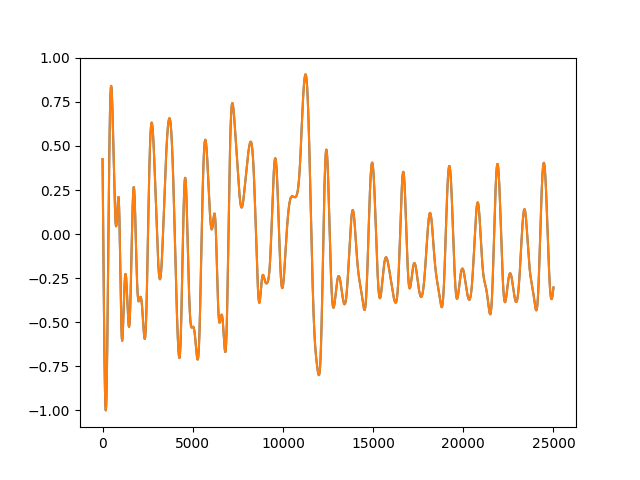

In [87]:
plt.plot(var1)
plt.plot(var1_norm)
plt.show()

In [88]:
def sigmoid(x, deriv=False):
    if deriv:
        return x * (1 - x)
    else:
        return 1 / (1 + np.exp(-x))

In [100]:
#Architecture & Hyperparameters
layer_in = 5
layer1 = 500
layer_out = 5
alpha = 0.01

# Weight initialization
np.random.seed(1)
#Input -> l1 Weight matrix has to be np.shape = (layer_in + 1, layer1) extra bias term
w01 = 2*np.random.random((layer_in + 1, layer1)) - 1
#l1 -> Output Weight matrix has to be np.shape = (layer_1 + 1, layer_out) extra bias term
w12 = 2*np.random.random((layer1 + 1, layer_out)) - 1

In [101]:
# Subset Samples for training, validation
# Construct the proper lengths for the input and output
num_ex = 20000
x_all = np.empty(shape=(num_ex, layer_in))
y_all = np.empty(shape=(num_ex, layer_out))
for i in xrange(num_ex - layer_in - layer_out):
    x_all[i, :] = var1[i:i+layer_in]
    y_all[i, :] = var1[i+layer_in:i+layer_in+layer_out]
# for i in xrange(num_ex):
#     x_all[i, :] = var1_norm[i:i+layer_in]
#     y_all[i, :] = var1_norm[i+layer_in:i+layer_in+layer_out]

    

# For now, choose first few for training, later it's better to choose a random sample
train_examples = int(num_ex)
x_train = x_all[0:train_examples,:]
y_train = y_all[0:train_examples,:]

<IPython.core.display.Javascript object>


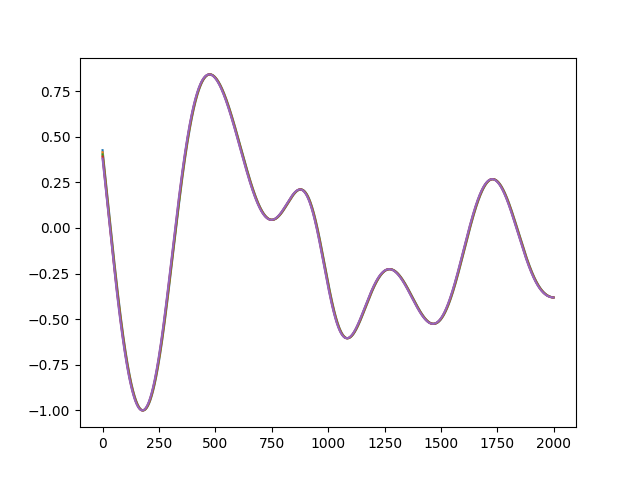

In [102]:
plt.plot(x_train[0:2000])
plt.show()

In [103]:
#Training
iterations = 10000
# batch_size controls how many examples the training algorithm uses each time
batch_size = 20

In [98]:
tstart = time.time()
counter = 0
while (counter < iterations):

    # randomize which part of the training set we use
#    train_idx = np.random.randint(0, train_examples, size=(batch_size))
    # feed the input in order
    train_idx = np.arange(counter % (x_train.shape[0] - batch_size), counter % (x_train.shape[0] - batch_size) + batch_size)

    # forward prop
    # load in input & label
    x0 = np.vstack((np.ones((batch_size)), x_train[train_idx,:].T)) # shape (layer_in + 1, batch_size)
    y = y_train[train_idx,:].T # shape (layer_out, batch_size)

    # propagate forward 
    x1 = np.vstack((np.ones((batch_size)), sigmoid(w01.T.dot(x0)))) # shape (layer_1 + 1, batch_size)
    x2 = w12.T.dot(x1) # shape (layer_out, batch_size)

    # backprop
    # calculate errors
    tot_error = sum(sum((x2 - y)**2))
    l2_delta = (x2 - y) # shape (layer_out, batch_size)
    l1_delta = sigmoid(x1, True) * (w12.dot(l2_delta)) # shape (layer_1 + 1, batch_size)

    # calculate gradients
    l2_grad = l2_delta[np.newaxis, :, :] * x1[:, np.newaxis, :] # shape (layer_1 + 1, layer_out, batch_size)
    l1_grad = l1_delta[np.newaxis, 1:, :] * x0[:, np.newaxis, :] # shape (layer_in + 1, layer_1, batch_size)

    # find total gradient across all examples
    l2_totgrad = np.average(l2_grad, axis=2) # shape (layer_1 + 1, layer_out)
    l1_totgrad = np.average(l1_grad, axis=2) # shape (layer_in + 1, layer_1)

    if counter % 1000 == 0:
        print ("Iteration %d, Error: %f" % (counter, tot_error))
    counter += 1

    # update weights
    w12 += -alpha*l2_totgrad/np.sqrt(counter) # update weight 1 -> out
    w01 += -alpha*l1_totgrad/np.sqrt(counter) # update weight in -> 1
        
print ("Training to %f error rate took %d seconds." % (tot_error, time.time()-tstart))

# Validation
def validate():
    # might be a crude way of defining our validation set
    batch_size = num_ex - train_examples
    val_idx = np.random.randint(train_examples, num_ex, size=(batch_size))
    
    x0 = np.vstack((np.ones((batch_size)), x_all[val_idx,:].T)) # shape (layer_in + 1, batch_size)
    y = y_all[val_idx,:].T # shape (layer_out, batch_size)

    # propagate forward 
    x1 = np.vstack((np.ones((batch_size)), sigmoid(w01.T.dot(x0)))) # shape (layer_1 + 1, batch_size)
    x2 = w12.T.dot(x1) # shape (layer_out, batch_size)

    # backprop
    # calculate errors
    tot_error = sum(sum((x2 - y)**2 / (2 * batch_size)))
    return tot_error

def predict(t_start, time_steps, data):
    prediction_window = np.arange(t_start, t_start + time_steps)
    x_true = np.array(data[0:t_start + time_steps, np.newaxis])
    x_predict = np.array(data[0:t_start + time_steps, np.newaxis])
    for i in xrange(time_steps):
        if i == 0:
            x0 = np.vstack(([1], data[t_start - layer_in:t_start, np.newaxis]))
        elif (i < layer_in):
            x0 = np.vstack(([1], x0[2:layer_in - i + 2], x_predict[0:i]))
        else:
            x0 = np.vstack(([1], x_predict[i-layer_in:i]))
        
        x1 = np.vstack(([1], sigmoid(w01.T.dot(x0)))) # shape (layer_1 + 1, 1)
        x2 = w12.T.dot(x1) # shape (layer_out, 1)
        x_predict[t_start + i] = x2[0]
    print("Root mean square error: %f" % (np.sqrt(sum((x_predict[prediction_window] - x_true[prediction_window])**2))))
    return(x_true, x_predict)

Iteration 0, Error: 10.843534
Iteration 1000, Error: 0.179278
Iteration 2000, Error: 0.003006
Iteration 3000, Error: 0.150779
Iteration 4000, Error: 0.270701
Iteration 5000, Error: 0.000041
Iteration 6000, Error: 0.047770
Iteration 7000, Error: 0.339701
Iteration 8000, Error: 0.020303
Iteration 9000, Error: 0.000141
Training to 0.001886 error rate took 4 seconds.


Root mean square error: 353.603090


<IPython.core.display.Javascript object>


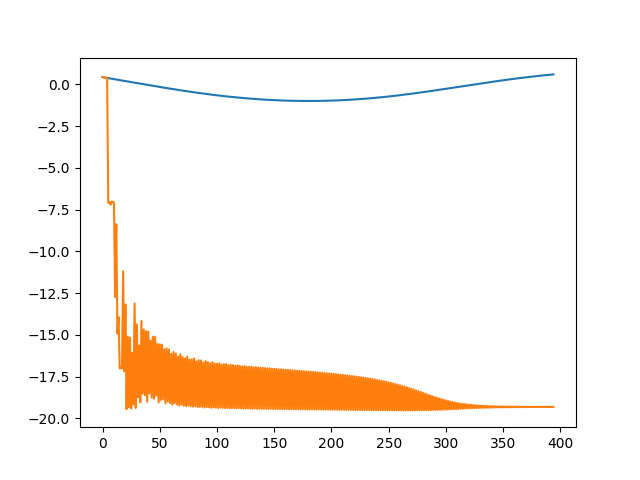

In [104]:
#print("Validation set test:", np.round(validate(), 3))

t_start = 5
t_steps = 400 - 10
true, prediction = predict(t_start, t_steps, var1)
# plt.scatter(np.arange(0, t_start + t_steps), true)
# plt.scatter(np.arange(0, t_start + t_steps), prediction)

plt.plot(true)
plt.plot(prediction)
plt.show()

In [440]:
1000 % 499

2